Loading tabular datasets...


[I 2026-04-13 19:26:06,801] A new study created in memory with name: no-name-d38ecdb3-016e-4932-9447-fbb91b8fe54b


Starting Hyperparameter Optimization (10 trials)...


Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-13 19:26:28,299] Trial 0 finished with value: 0.9079427661028044 and parameters: {'learning_rate': 0.039232897055388155, 'depth': 7, 'l2_leaf_reg': 8.187661534093017, 'random_strength': 7.153683700724654e-08, 'bagging_temperature': 0.004622303997522392}. Best is trial 0 with value: 0.9079427661028044.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-13 19:26:44,823] Trial 1 finished with value: 0.8987707962895328 and parameters: {'learning_rate': 0.01697649549965436, 'depth': 5, 'l2_leaf_reg': 3.1513470198047755, 'random_strength': 9.990520224143004e-05, 'bagging_temperature': 0.194826608963937}. Best is trial 0 with value: 0.9079427661028044.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-13 19:27:22,469] Trial 2 finished with value: 0.8978688027862092 and parameters: {'learning_rate': 0.0038841729526453974, 'depth': 10, 'l2_leaf_reg': 7.30

Best Trial Score: 0.9119
Best Params: {'learning_rate': 0.03404245661062897, 'depth': 9, 'l2_leaf_reg': 7.166350321220219, 'random_strength': 2.2247284640522906, 'bagging_temperature': 0.6750350411363092}

Training final model with optimized parameters...
0:	total: 99.5ms	remaining: 3m 18s
100:	total: 9.25s	remaining: 2m 53s
200:	total: 18.4s	remaining: 2m 44s
300:	total: 27.1s	remaining: 2m 32s
400:	total: 36s	remaining: 2m 23s
500:	total: 45.4s	remaining: 2m 15s
600:	total: 54.2s	remaining: 2m 6s
700:	total: 1m 2s	remaining: 1m 56s
800:	total: 1m 11s	remaining: 1m 46s
900:	total: 1m 19s	remaining: 1m 37s
1000:	total: 1m 28s	remaining: 1m 27s
1100:	total: 1m 36s	remaining: 1m 18s
1200:	total: 1m 45s	remaining: 1m 10s
1300:	total: 1m 53s	remaining: 1m 1s
1400:	total: 2m 2s	remaining: 52.2s
1500:	total: 2m 10s	remaining: 43.3s
1600:	total: 2m 18s	remaining: 34.6s
1700:	total: 2m 27s	remaining: 25.9s
1800:	total: 2m 36s	remaining: 17.2s
1900:	total: 2m 45s	remaining: 8.62s
1999:	total: 2

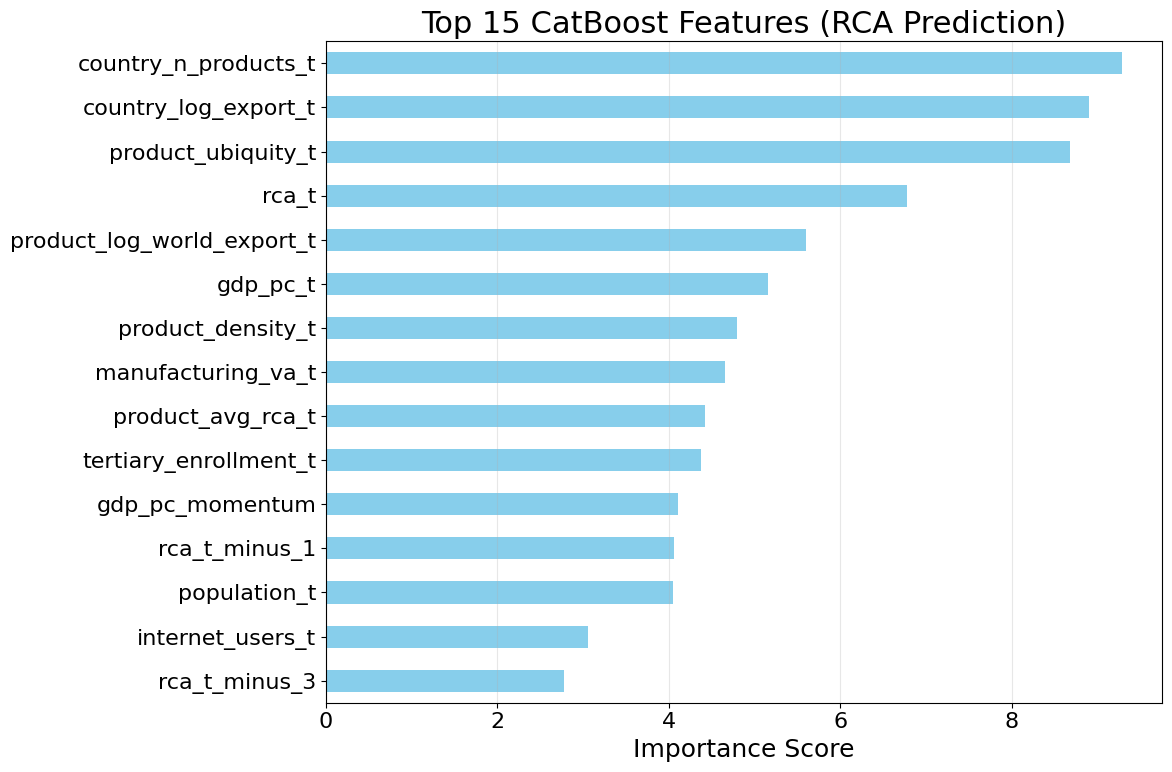

In [8]:
import pandas as pd
import numpy as np
import os
import catboost as cb
import optuna
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, classification_report
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATA_DIR = "data"
TRAIN_PATH = r"C:\Users\Ashwa\Ash_projects\Indigo_Research\data\TabularDataset\train_tabular.csv"
TEST_PATH = r"C:\Users\Ashwa\Ash_projects\Indigo_Research\data\TabularDataset\test_tabular.csv"


print("Loading tabular datasets...")
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
# Identifiers we don't want the model to "learn" literal values for 
# except as categorical groupings
DROP_COLS = ['country_id', 'product_id', 'anchor_year', 'target_future_rca']

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df['target_future_rca']

X_test = test_df.drop(columns=DROP_COLS)
y_test = test_df['target_future_rca']
# Identify Categorical Features if we were using them as raw strings
# But here they are IDs, we treat them as numeric features for now 
# unless you want to pass them as cat_features.

# 1. OPTUNA OPTIMIZATION
def objective(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "border_count": 254,
        "verbose": False,
        "eval_metric": "AUC",
        "task_type": "GPU", # Change to "GPU" if you have a configured GPU
    }
    
    # Use simple Train/Val split within the training set for optimization
    model = cb.CatBoostClassifier(**params)
    model.fit(X_train, y_train, early_stopping_rounds=50, verbose=False)
    
    preds = model.predict_proba(X_train)[:, 1]
    return roc_auc_score(y_train, preds)

print("Starting Hyperparameter Optimization (10 trials)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)
print(f"Best Trial Score: {study.best_value:.4f}")
print("Best Params:", study.best_params)
# 2. FINAL TRAINING
print("\nTraining final model with optimized parameters...")
final_params = {**study.best_params, "iterations": 2000, "verbose": 100, "eval_metric": "AUC"}
model = cb.CatBoostClassifier(**final_params)
model.fit(X_train, y_train)
# 3. EVALUATION
y_prob = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)
# Calculate Optimal F1
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_f1 = np.max(f1_scores)
best_thresh = thresholds[np.argmax(f1_scores)]
print("\n" + "="*30)
print("CATBOOST BENCHMARK RESULTS")
print("="*30)
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Optimal F1 Score: {best_f1:.4f} (at threshold {best_thresh:.4f})")
print("\nClassification Report (at Optimal Threshold):")
y_pred_opt = (y_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_opt))
# 4. VISUALIZATION (Big Fonts for Visibility)
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(12, 8))

# Feature Importance
feat_importances = pd.Series(model.get_feature_importance(), index=X_train.columns)
feat_importances.nlargest(15).sort_values().plot(kind='barh', color='skyblue')

plt.title("Top 15 CatBoost Features (RCA Prediction)", fontsize=22)
plt.xlabel("Importance Score", fontsize=18)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



In [9]:
from sklearn.metrics import roc_auc_score

def calculate_top_k_metrics(y_true, y_prob, k=50):
    """
    Calculates AUC, Precision@K, and Recall@K.
    """
    # 1. AUC Score
    auc = roc_auc_score(y_true, y_prob)

    # 2. Sort true labels by predicted probabilities in descending order
    # This simulates "picking the top K most likely activations"
    results = pd.DataFrame({'true': y_true, 'prob': y_prob})
    top_k = results.sort_values(by='prob', ascending=False).head(k)

    # 3. Precision@K = (Correct predictions in top K) / K
    precision_at_k = top_k['true'].sum() / k

    # 4. Recall@K = (Correct predictions in top K) / (Total true positives in dataset)
    total_positives = y_true.sum()
    recall_at_k = top_k['true'].sum() / (total_positives + 1e-8)

    return auc, precision_at_k, recall_at_k

# --- Usage after fitting your final_model ---
# X_test and y_test come from your test_tabular.csv
y_probs = model.predict_proba(X_test)[:, 1]

auc_val, p50, r50 = calculate_top_k_metrics(y_test, y_probs, k=50)

print("\n" + "="*35)
print(f"CATBOOST TOP-50 PERFORMANCE")
print("="*35)
print(f"ROC-AUC:      {auc_val:.4f}")
print(f"Precision@50: {p50:.4f}")
print(f"Recall@50:    {r50:.4f}")
print("="*35)



CATBOOST TOP-50 PERFORMANCE
ROC-AUC:      0.8960
Precision@50: 0.9400
Recall@50:    0.0025


Loading tabular datasets...
Detected Class Imbalance: 1415008 neg / 283355 pos
Setting scale_pos_weight to: 4.99

Training final model with class-balance parameters...
0:	learn: 0.7964355	test: 0.7892014	best: 0.7892014 (0)	total: 3.52s	remaining: 1h 57m 19s
100:	learn: 0.8176410	test: 0.7934817	best: 0.7970342 (21)	total: 6.99s	remaining: 2m 11s
bestTest = 0.797034201
bestIteration = 21
Shrink model to first 22 iterations.

CATBOOST OPTIMIZED RESULTS
Optimal Threshold for F1: 0.6592
Max F1 Score: 0.6149
Recall at this threshold: 0.6364

Classification Report (at Optimal Threshold):
              precision    recall  f1-score   support

           0       0.94      0.93      0.93    109672
           1       0.59      0.64      0.61     18477

    accuracy                           0.89    128149
   macro avg       0.77      0.78      0.77    128149
weighted avg       0.89      0.89      0.89    128149



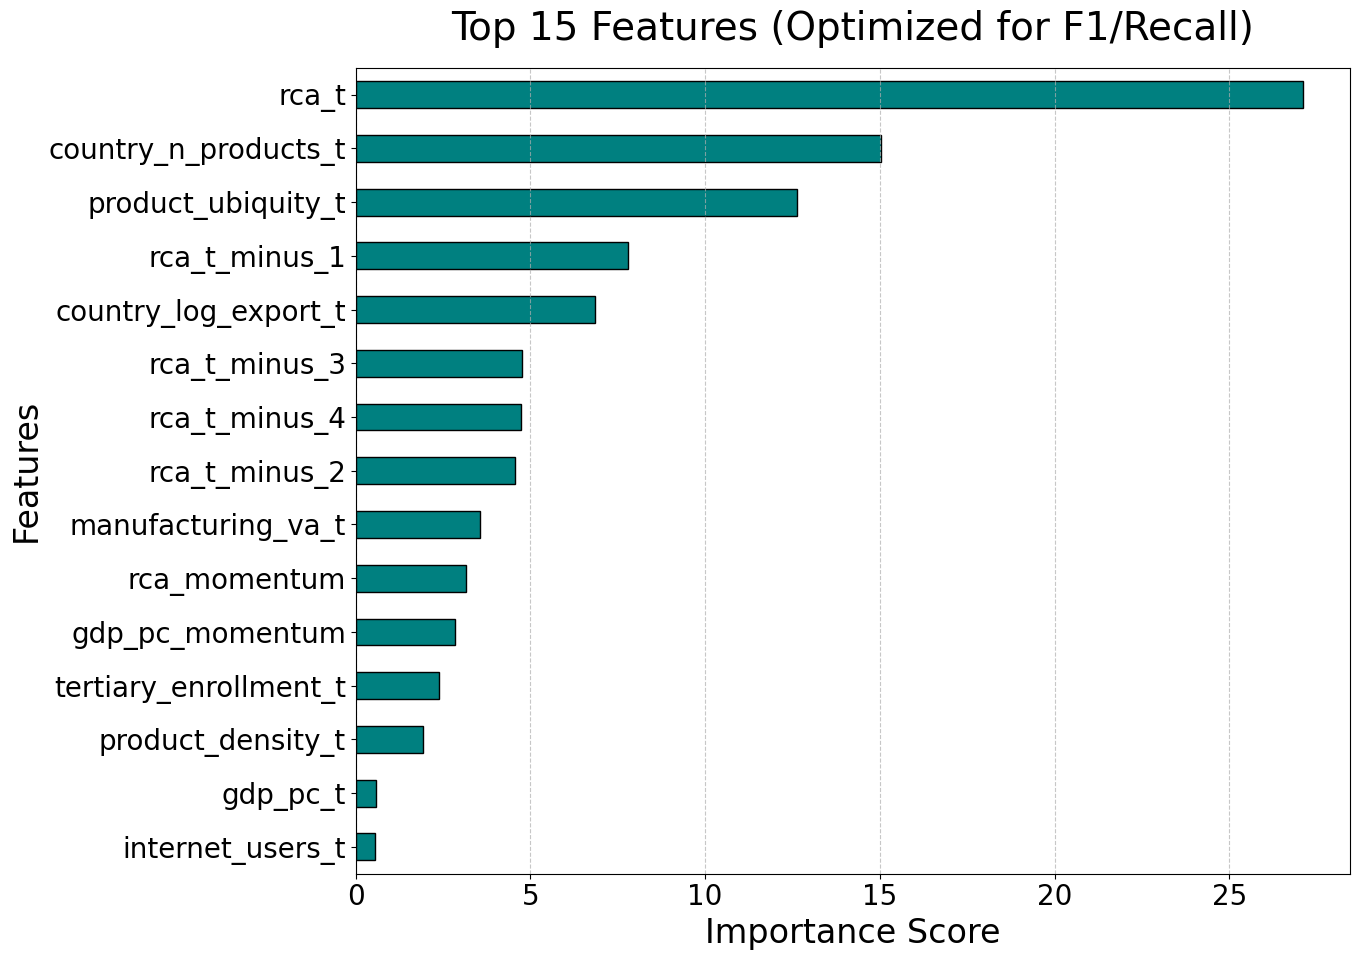

In [1]:
import pandas as pd
import numpy as np
import os
import catboost as cb
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_recall_curve, classification_report
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
TRAIN_PATH = r"C:\Users\Ashwa\Ash_projects\Indigo_Research\data\TabularDataset\train_tabular.csv"
TEST_PATH = r"C:\Users\Ashwa\Ash_projects\Indigo_Research\data\TabularDataset\test_tabular.csv"

print("Loading tabular datasets...")
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

DROP_COLS = ['country_id', 'product_id', 'anchor_year', 'target_future_rca']

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df['target_future_rca']
X_test = test_df.drop(columns=DROP_COLS)
y_test = test_df['target_future_rca']

# --- CALCULATE OPTIMAL SCALE_POS_WEIGHT ---
# Based on your graph: ~1.7M negatives / 0.28M positives ≈ 6.0
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
optimal_weight = num_neg / num_pos
print(f"Detected Class Imbalance: {num_neg} neg / {num_pos} pos")
print(f"Setting scale_pos_weight to: {optimal_weight:.2f}")

# --- FINAL TRAINING WITH OPTIMAL PARAMETERS ---
# We use 'Logloss' as the objective but 'F1' as the eval_metric 
# to ensure the model prioritizes the balance during training.
final_params = {
    "iterations": 2000,
    "learning_rate": 0.05,
    "depth": 8,
    "l2_leaf_reg": 3,
    "scale_pos_weight": optimal_weight, # CRITICAL: Fixes the Recall drop
    "eval_metric": "F1",               # Focuses on F1 during training
    "task_type": "GPU",                # Kept from your base code
    "verbose": 100,
    "early_stopping_rounds": 100,
    "random_seed": 42
}

print("\nTraining final model with class-balance parameters...")
model = cb.CatBoostClassifier(**final_params)
model.fit(X_train, y_train, eval_set=(X_test, y_test))

# --- EVALUATION & THRESHOLD TUNING ---
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve to find the absolute best F1 threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_f1 = f1_scores[best_idx]
best_thresh = thresholds[best_idx]

print("\n" + "="*30)
print("CATBOOST OPTIMIZED RESULTS")
print("="*30)
print(f"Optimal Threshold for F1: {best_thresh:.4f}")
print(f"Max F1 Score: {best_f1:.4f}")
print(f"Recall at this threshold: {recall[best_idx]:.4f}")

print("\nClassification Report (at Optimal Threshold):")
y_pred_opt = (y_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_opt))

# --- VISUALIZATION (Large Fonts) ---
plt.rcParams.update({'font.size': 20}) # Increased for better visibility
plt.figure(figsize=(14, 10))

# Feature Importance
feat_importances = pd.Series(model.get_feature_importance(), index=X_train.columns)
feat_importances.nlargest(15).sort_values().plot(kind='barh', color='teal', edgecolor='black')

plt.title("Top 15 Features (Optimized for F1/Recall)", fontsize=28, pad=20)
plt.xlabel("Importance Score", fontsize=24)
plt.ylabel("Features", fontsize=24)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [2]:
from sklearn.metrics import roc_auc_score

def calculate_top_k_metrics(y_true, y_prob, k=50):
    """
    Calculates AUC, Precision@K, and Recall@K.
    """
    # 1. AUC Score
    auc = roc_auc_score(y_true, y_prob)

    # 2. Sort true labels by predicted probabilities in descending order
    # This simulates "picking the top K most likely activations"
    results = pd.DataFrame({'true': y_true, 'prob': y_prob})
    top_k = results.sort_values(by='prob', ascending=False).head(k)

    # 3. Precision@K = (Correct predictions in top K) / K
    precision_at_k = top_k['true'].sum() / k

    # 4. Recall@K = (Correct predictions in top K) / (Total true positives in dataset)
    total_positives = y_true.sum()
    recall_at_k = top_k['true'].sum() / (total_positives + 1e-8)

    return auc, precision_at_k, recall_at_k

# --- Usage after fitting your final_model ---
# X_test and y_test come from your test_tabular.csv
y_probs = model.predict_proba(X_test)[:, 1]

auc_val, p50, r50 = calculate_top_k_metrics(y_test, y_probs, k=50)

print("\n" + "="*35)
print(f"CATBOOST TOP-50 PERFORMANCE")
print("="*35)
print(f"ROC-AUC:      {auc_val:.4f}")
print(f"Precision@50: {p50:.4f}")
print(f"Recall@50:    {r50:.4f}")
print("="*35)



CATBOOST TOP-50 PERFORMANCE
ROC-AUC:      0.8892
Precision@50: 0.9200
Recall@50:    0.0025
